<a href="https://colab.research.google.com/github/jamottansihite/Jamottan-/blob/main/ETS_2330209040018.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jamottan Fierdianto_2330209040018

PROYEK AKTUARIA (DATA BPS SP2020)
 Survival + Hazard + Mortalitas

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ATA BPS (Sensus Penduduk 2020)
# Sumber: BPS - Struktur Umur Penduduk Indonesia

In [41]:
umur = ["0-4","5-9","10-14","15-19","20-24","25-29","30-34","35-39",
        "40-44","45-49","50-54","55-59","60-64","65-69","70-74","75+"]

populasi = np.array([
    15453694, 23347669, 23749949, 23122993,
    22951517, 21577605, 21123845, 22158305,
    20703361, 18531366, 16149933, 13063387,
    10274175, 6786266, 4148581, 5026744
])


NORMALISASI (radix = 100000)

In [42]:
total = sum(populasi)
lx = (populasi / total) * 100000

# agar memenuhi tabel mortalitas (monoton menurun)
lx = np.sort(lx)[::-1]

dx, qx, px

In [43]:
dx = np.zeros(len(lx))
qx = np.zeros(len(lx))
px = np.zeros(len(lx))

for i in range(len(lx)-1):
    dx[i] = lx[i] - lx[i+1]
    qx[i] = dx[i] / lx[i]
    px[i] = 1 - qx[i]

dx[-1] = lx[-1]
qx[-1] = 1
px[-1] = 0


Survival Function S(x)

In [44]:
Sx = lx / lx[0]

Hazard Function h(x)

In [45]:
hx = qx / px
hx[-1] = 0

/tmp/ipykernel_915/1515810054.py:1: RuntimeWarning: divide by zero encountered in divide
  hx = qx / px


Tx dan ex

In [46]:
Tx = np.array([sum(lx[i:]) for i in range(len(lx))])
ex = Tx / lx

TABEL

In [47]:
df = pd.DataFrame({
    "Umur": umur,
    "lx": np.round(lx,2),
    "dx": np.round(dx,2),
    "qx": np.round(qx,4),
    "px": np.round(px,4),
    "S(x)": np.round(Sx,4),
    "h(x)": np.round(hx,4),
    "e(x)": np.round(ex,2)
})

print("=== TABEL MORTALITAS (DATA BPS 2020) ===")
display(df)

=== TABEL MORTALITAS (DATA BPS 2020) ===


,Umur,lx,dx,qx,px,S(x),h(x),e(x)
0,0-4,8856.32,150.01,0.0169,0.9831,1.0000,0.0172,11.29
1,5-9,8706.31,83.78,0.0096,0.9904,0.9831,0.0097,10.47
2,10-14,8622.53,63.94,0.0074,0.9926,0.9736,0.0075,9.56
3,15-19,8558.59,295.79,0.0346,0.9654,0.9664,0.0358,8.62
4,20-24,8262.80,216.54,0.0262,0.9738,0.9330,0.0269,7.90
5,25-29,8046.26,169.21,0.0210,0.9790,0.9085,0.0215,7.08
6,30-34,7877.05,156.80,0.0199,0.9801,0.8894,0.0203,6.21
7,35-39,7720.26,809.93,0.1049,0.8951,0.8717,0.1172,5.32
8,40-44,6910.32,888.03,0.1285,0.8715,0.7803,0.1475,4.83
9,45-49,6022.29,259.63,0.0431,0.9569,0.6800,0.0451,4.39


GRAFIK

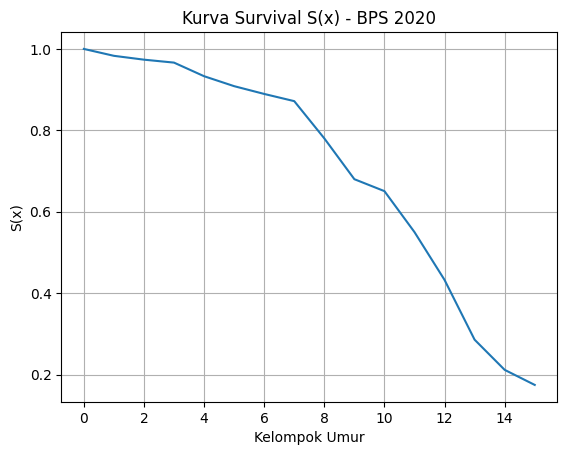

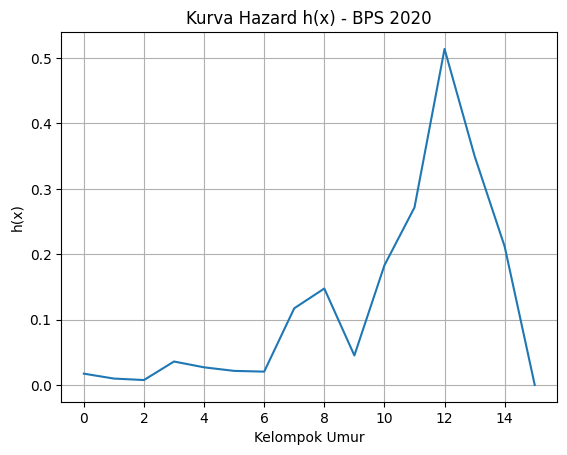

In [48]:
# Survival
plt.figure()
plt.plot(Sx)
plt.title("Kurva Survival S(x) - BPS 2020")
plt.xlabel("Kelompok Umur")
plt.ylabel("S(x)")
plt.grid()
plt.show()

# Hazard
plt.figure()
plt.plot(hx)
plt.title("Kurva Hazard h(x) - BPS 2020")
plt.xlabel("Kelompok Umur")
plt.ylabel("h(x)")
plt.grid()
plt.show()